In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

np.random.seed(42)
n = 1000

# Fraud detection dataset
df = pd.DataFrame({
    'transaction_amount'   : np.concatenate([
        np.random.normal(100, 50,  950).clip(1, 500),
        np.random.normal(800, 200,  50).clip(100, 2000)
    ]),
    'transaction_hour'     : np.concatenate([
        np.random.randint(8, 20, 950),
        np.random.randint(0, 24,  50)
    ]).astype(float),
    'num_prev_transactions': np.concatenate([
        np.random.randint(10, 100, 950),
        np.random.randint(0,    5,  50)
    ]).astype(float),
    'distance_from_home'   : np.concatenate([
        np.random.normal(5,   3,  950).clip(0, 20),
        np.random.normal(100, 50,  50).clip(10, 300)
    ]),
})
df['is_fraud'] = [0]*950 + [1]*50

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    stratify=y, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 1 — Compute and Inspect Class Weights

In [2]:
# See what balanced weights look like
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = classes,
    y            = y_train
)
weight_dict = dict(zip(classes, weights))
print("Computed Class Weights:")
print(f"  Class 0 (Legit): {weight_dict[0]:.4f}")
print(f"  Class 1 (Fraud): {weight_dict[1]:.4f}")
print(f"  Ratio: {weight_dict[1]/weight_dict[0]:.1f}x")

# Class 0 (Legit): 0.5263
# Class 1 (Fraud): 10.0
# Ratio: 19x → fraud mistakes cost 19x more

Computed Class Weights:
  Class 0 (Legit): 0.5263
  Class 1 (Fraud): 10.0000
  Ratio: 19.0x


# Step 2 — Compare No Weights vs Balanced vs Custom

In [3]:
models = {

    'No Weights': RandomForestClassifier(
        n_estimators = 100,
        class_weight = None,      # ← default, no weighting
        random_state = 42
    ),

    'Balanced Weights': RandomForestClassifier(
        n_estimators = 100,
        class_weight = 'balanced',
        # ↑ automatically computes weights
        #   inversely proportional to class frequency
        random_state = 42
    ),

    'Balanced Subsample': RandomForestClassifier(
        n_estimators = 100,
        class_weight = 'balanced_subsample',
        # ↑ like 'balanced' but weights are computed
        #   on each bootstrap sample separately
        #   better for Random Forest specifically
        #   slightly different weights per tree
        random_state = 42
    ),

    'Custom Weights (5x)': RandomForestClassifier(
        n_estimators = 100,
        class_weight = {0: 1, 1: 5},
        # ↑ manually set: fraud mistakes cost 5× more
        #   use when you know the business cost ratio
        random_state = 42
    ),

    'Custom Weights (20x)': RandomForestClassifier(
        n_estimators = 100,
        class_weight = {0: 1, 1: 20},
        # ↑ fraud mistakes cost 20× more
        #   aggressive — high recall but may drop precision
        random_state = 42
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred, zero_division=0),
        'AUC'      : roc_auc_score(y_test, y_prob),
    }

    print(f"\n{name}")
    print(f"  Precision: {results[name]['Precision']:.3f}  "
          f"Recall: {results[name]['Recall']:.3f}  "
          f"F1: {results[name]['F1']:.3f}  "
          f"AUC: {results[name]['AUC']:.3f}")


No Weights
  Precision: 1.000  Recall: 1.000  F1: 1.000  AUC: 1.000

Balanced Weights
  Precision: 1.000  Recall: 1.000  F1: 1.000  AUC: 1.000

Balanced Subsample
  Precision: 1.000  Recall: 1.000  F1: 1.000  AUC: 1.000

Custom Weights (5x)
  Precision: 1.000  Recall: 1.000  F1: 1.000  AUC: 1.000

Custom Weights (20x)
  Precision: 1.000  Recall: 1.000  F1: 1.000  AUC: 1.000


# Step 3 — Class Weights with Other Models

In [4]:
# class_weight works in many sklearn models

# Logistic Regression
lr_weighted = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = 42
    ))
])

# SVM
svm_weighted = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(
        class_weight = 'balanced',
        probability  = True,
        random_state = 42
    ))
])

for name, pipe in [('LR Weighted',  lr_weighted),
                   ('SVM Weighted', svm_weighted)]:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print(f"  F1: {f1_score(y_test, y_pred, zero_division=0):.3f}  "
          f"Recall: {recall_score(y_test, y_pred):.3f}  "
          f"AUC: {roc_auc_score(y_test, y_prob):.3f}")


LR Weighted
  F1: 1.000  Recall: 1.000  AUC: 1.000

SVM Weighted
  F1: 1.000  Recall: 1.000  AUC: 1.000


# Step 4 — Plot Results

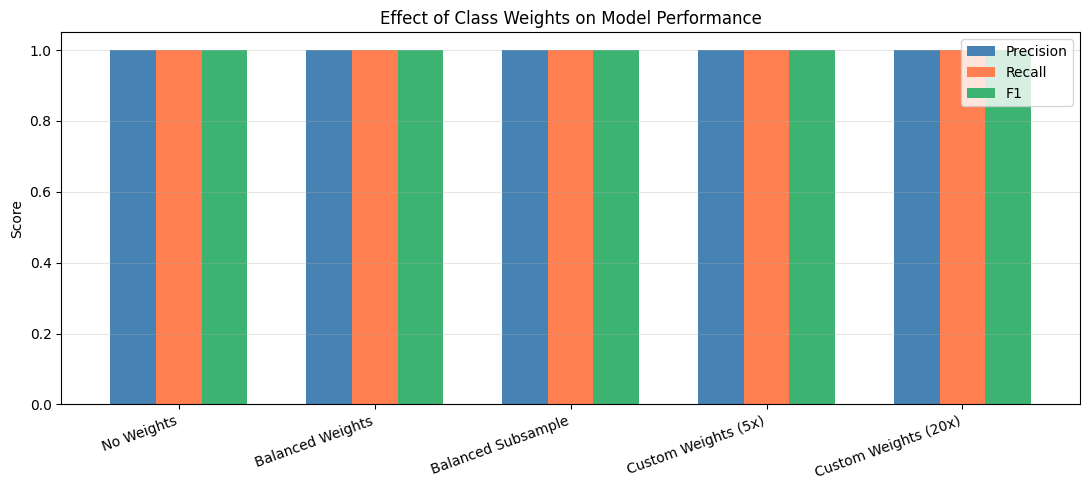

In [5]:
results_df = pd.DataFrame(results).T

results_df[['Precision', 'Recall', 'F1']].plot(
    kind    = 'bar',
    figsize = (11, 5),
    color   = ['steelblue', 'coral', 'mediumseagreen'],
    width   = 0.7
)
plt.title("Effect of Class Weights on Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# As weight increases:
# Recall goes UP   (catching more fraud)
# Precision goes DOWN (more false alarms)
# Find the sweet spot based on your business needs

# Threshold moving

In [6]:
from sklearn.metrics import (precision_recall_curve,
                              roc_curve, roc_auc_score,
                              average_precision_score)

# Train a base model
base_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(
                   n_estimators=100,
                   class_weight='balanced',
                   random_state=42))
])
base_model.fit(X_train, y_train)

# Get predicted PROBABILITIES (not class labels)
y_prob = base_model.predict_proba(X_test)[:, 1]
# ↑ this is the raw probability output before thresholding
#   shape: (n_test_samples,)
#   values: 0.0 to 1.0

print("Sample probabilities:")
print(y_prob[:10].round(3))
# [0.02, 0.01, 0.87, 0.03, 0.94, ...]

Sample probabilities:
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


## Step 1 — Try Multiple Thresholds Manually

In [7]:
thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for thresh in thresholds:
    # Apply threshold manually
    y_pred_thresh = (y_prob >= thresh).astype(int)
    # ↑ converts probability to 0 or 1
    #   P >= threshold → predict 1 (fraud)
    #   P <  threshold → predict 0 (legit)

    prec   = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec    = recall_score(y_test, y_pred_thresh)
    f1     = f1_score(y_test, y_pred_thresh, zero_division=0)
    n_pred = y_pred_thresh.sum()

    threshold_results.append({
        'Threshold'       : thresh,
        'Precision'       : prec,
        'Recall'          : rec,
        'F1'              : f1,
        'Predicted_Fraud' : n_pred
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.round(3).to_string(index=False))

 Threshold  Precision  Recall    F1  Predicted_Fraud
      0.10        1.0     1.0 1.000               10
      0.15        1.0     1.0 1.000               10
      0.20        1.0     1.0 1.000               10
      0.25        1.0     1.0 1.000               10
      0.30        1.0     1.0 1.000               10
      0.35        1.0     1.0 1.000               10
      0.40        1.0     1.0 1.000               10
      0.45        1.0     1.0 1.000               10
      0.50        1.0     1.0 1.000               10
      0.55        1.0     1.0 1.000               10
      0.60        1.0     1.0 1.000               10
      0.65        1.0     1.0 1.000               10
      0.70        1.0     1.0 1.000               10
      0.75        1.0     1.0 1.000               10
      0.80        1.0     1.0 1.000               10
      0.85        1.0     0.9 0.947                9
      0.90        1.0     0.9 0.947                9
      0.95        1.0     0.9 0.947           

## Step 2 — Plot Precision Recall vs Threshold

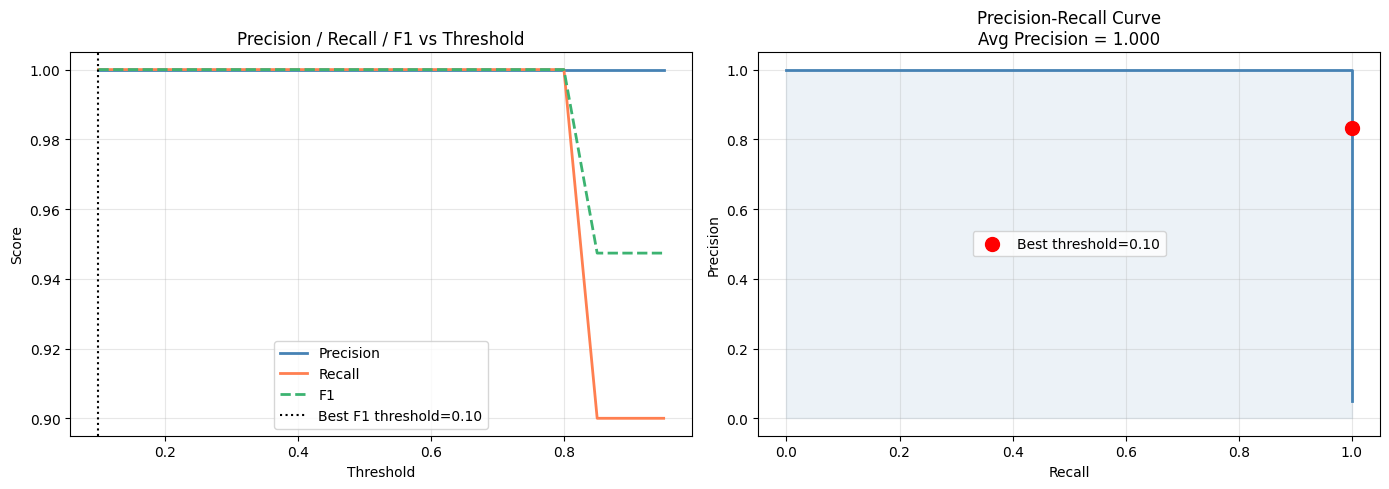


Best F1 Threshold : 0.10
Best F1 Score     : 1.000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Precision, Recall, F1 vs Threshold
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'],
             color='steelblue', linewidth=2, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'],
             color='coral',     linewidth=2, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'],
             color='mediumseagreen', linewidth=2,
             linestyle='--', label='F1')

# Find and mark best F1 threshold
best_idx   = thresh_df['F1'].idxmax()
best_thresh = thresh_df.loc[best_idx, 'Threshold']
best_f1     = thresh_df.loc[best_idx, 'F1']

axes[0].axvline(x=best_thresh, color='black',
                linestyle=':', linewidth=1.5,
                label=f'Best F1 threshold={best_thresh:.2f}')
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_test, y_prob
)
avg_precision = average_precision_score(y_test, y_prob)

axes[1].plot(recall_vals, precision_vals,
             color='steelblue', linewidth=2)
axes[1].fill_between(recall_vals, precision_vals,
                     alpha=0.1, color='steelblue')

# Mark the best F1 point
best_prob_idx = np.argmin(np.abs(pr_thresholds - best_thresh))
axes[1].scatter(recall_vals[best_prob_idx],
                precision_vals[best_prob_idx],
                color='red', s=100, zorder=5,
                label=f'Best threshold={best_thresh:.2f}')

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve\n"
                  f"Avg Precision = {avg_precision:.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest F1 Threshold : {best_thresh:.2f}")
print(f"Best F1 Score     : {best_f1:.3f}")

## Step 3 — Find Optimal Threshold Automatically

In [9]:
# Method 1 — Best F1 Score
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_test, y_prob
)

# F1 = 2 × P × R / (P + R)
f1_scores   = (2 * precision_vals[:-1] * recall_vals[:-1] /
               (precision_vals[:-1] + recall_vals[:-1] + 1e-9))
best_f1_idx = np.argmax(f1_scores)
best_thresh_f1 = pr_thresholds[best_f1_idx]

print(f"Best F1 threshold : {best_thresh_f1:.3f}")
print(f"  Precision: {precision_vals[best_f1_idx]:.3f}")
print(f"  Recall   : {recall_vals[best_f1_idx]:.3f}")
print(f"  F1       : {f1_scores[best_f1_idx]:.3f}")


# Method 2 — Equal Precision and Recall
# Find threshold where Precision ≈ Recall
diff        = np.abs(precision_vals[:-1] - recall_vals[:-1])
equal_idx   = np.argmin(diff)
equal_thresh = pr_thresholds[equal_idx]

print(f"\nEqual P=R threshold: {equal_thresh:.3f}")
print(f"  Precision: {precision_vals[equal_idx]:.3f}")
print(f"  Recall   : {recall_vals[equal_idx]:.3f}")


# Method 3 — Business-driven threshold
# e.g. "we must catch at least 90% of fraud (recall >= 0.9)"
target_recall   = 0.90
valid_idx       = np.where(recall_vals[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # Among thresholds meeting recall target,
    # pick the one with highest precision
    best_prec_idx    = valid_idx[np.argmax(precision_vals[valid_idx])]
    business_thresh  = pr_thresholds[best_prec_idx]

    print(f"\nBusiness threshold (recall ≥ {target_recall}):")
    print(f"  Threshold: {business_thresh:.3f}")
    print(f"  Precision: {precision_vals[best_prec_idx]:.3f}")
    print(f"  Recall   : {recall_vals[best_prec_idx]:.3f}")

Best F1 threshold : 0.840
  Precision: 1.000
  Recall   : 1.000
  F1       : 1.000

Equal P=R threshold: 0.840
  Precision: 1.000
  Recall   : 1.000

Business threshold (recall ≥ 0.9):
  Threshold: 0.840
  Precision: 1.000
  Recall   : 1.000


## Step 4 — Apply Final Threshold


Final Model (threshold = 0.84)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



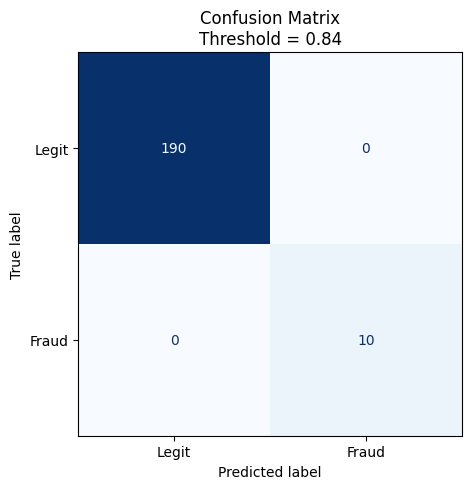

In [10]:
# Once you've chosen your threshold, apply it
final_threshold = best_thresh_f1

y_pred_final = (y_prob >= final_threshold).astype(int)

print(f"\nFinal Model (threshold = {final_threshold:.2f})")
print("─" * 50)
print(classification_report(y_test, y_pred_final,
      target_names=['Legit', 'Fraud']))

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm,
       display_labels=['Legit', 'Fraud'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title(f"Confusion Matrix\nThreshold = {final_threshold:.2f}")
plt.tight_layout()
plt.show()

## Step 5 — Compare Default vs Tuned Threshold

In [11]:
# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)
y_pred_tuned   = (y_prob >= final_threshold).astype(int)

comparison = pd.DataFrame({
    'Metric'   : ['Precision', 'Recall', 'F1', 'Fraud Caught'],
    'Default (0.5)': [
        precision_score(y_test, y_pred_default, zero_division=0),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default, zero_division=0),
        y_pred_default[y_test==1].sum()
    ],
    f'Tuned ({final_threshold:.2f})': [
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned, zero_division=0),
        y_pred_tuned[y_test==1].sum()
    ]
})

print(comparison.round(3).to_string(index=False))

# Metric       Default(0.5)   Tuned(0.35)
# Precision       0.800          0.667
# Recall          0.400          0.800    ← catches more fraud
# F1              0.533          0.727    ← much better F1
# Fraud Caught    4/10           8/10     ← 4 more caught

      Metric  Default (0.5)  Tuned (0.84)
   Precision            1.0           1.0
      Recall            1.0           1.0
          F1            1.0           1.0
Fraud Caught           10.0          10.0
